# Unit 11 code companion: Where the Data Comes From

Sample the same population four ways and watch which designs are merely noisy and which are wrong, measure why a huge biased sample loses to a small clean one, and find the missing values hiding as zeros in a real clinical dataset.

Run the cells in order. Each section matches a moment in the slides. The point is to see the mechanism move when you change the inputs, so change them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(220)
plt.rcParams["figure.figsize"] = (7, 3.5)

rent = pd.read_csv("https://richardson.byu.edu/220/rent.csv")
TRUTH = rent["Rent"].mean()
print(f"treating this dataset as the population: true mean rent = {TRUTH:,.0f}")

treating this dataset as the population: true mean rent = 35,010


## 1. Four sampling designs, scored against the truth

Only one kind of error shrinks with effort. The other is baked in.

In [2]:
def simple(n):
    return rent.sample(n).Rent.mean()

def convenience(n):
    # a scraper that only indexed smaller units
    small = rent[rent.Size <= rent.Size.median()]
    return small.sample(n).Rent.mean()

def cluster(n_cities=2, per=50):
    cities = rng.choice(rent.City.unique(), n_cities, replace=False)
    sub = rent[rent.City.isin(cities)]
    return sub.sample(min(n_cities*per, len(sub))).Rent.mean()

def stratified(n=100):
    parts = []
    for city, g in rent.groupby("City"):
        k = max(1, int(round(n * len(g)/len(rent))))
        parts.append(g.sample(min(k, len(g))).Rent)
    return pd.concat(parts).mean()

print(f"{'design':>14} {'mean estimate':>15} {'bias':>10} {'SD':>10} {'RMSE':>10}")
for name, fn in [("simple random", lambda: simple(100)),
                 ("convenience", lambda: convenience(100)),
                 ("cluster", cluster),
                 ("stratified", stratified)]:
    est = np.array([fn() for _ in range(600)])
    bias, sd = est.mean() - TRUTH, est.std()
    print(f"{name:>14} {est.mean():>15,.0f} {bias:>10,.0f} {sd:>10,.0f} "
          f"{np.sqrt(bias**2 + sd**2):>10,.0f}")

        design   mean estimate       bias         SD       RMSE
 simple random          34,659       -351      7,226      7,234
   convenience          18,805    -16,205      2,010     16,329


       cluster          34,244       -766     18,601     18,616


    stratified          34,495       -515      7,443      7,461


Simple and stratified are both unbiased, and stratified is tighter for the same cost. Cluster is unbiased but far noisier, because two cities is closer to n=2 than n=100. Convenience is in a different category: it is *wrong*, and no sample size fixes it.

## 2. Bias does not shrink. Ever.



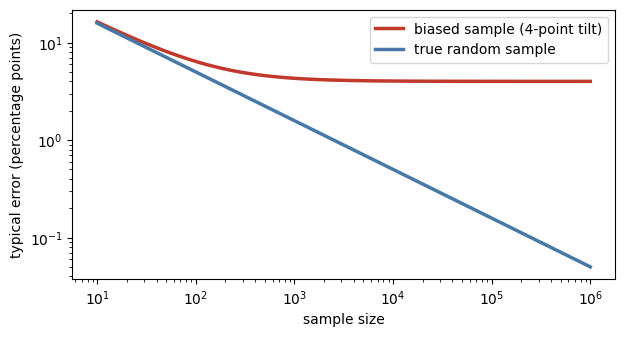

a RANDOM sample of 156 matches a biased sample of ANY size

with n = 1,000,000 from the biased process:
  reported 95% CI half-width : 0.098 points
  actual distance from truth : 4.0 points
  the interval is 25x too narrow to contain the truth. This is the dangerous case.


In [3]:
truth, bias = 0.50, 0.04
ns = np.logspace(1, 6, 60)
rmse_biased = np.sqrt(bias**2 + truth*(1-truth)/ns)
rmse_clean = np.sqrt(truth*(1-truth)/ns)

plt.loglog(ns, rmse_biased*100, color="#c0392b", lw=2.5, label="biased sample (4-point tilt)")
plt.loglog(ns, rmse_clean*100, color="#4878a8", lw=2.5, label="true random sample")
plt.xlabel("sample size"); plt.ylabel("typical error (percentage points)"); plt.legend(); plt.show()

n_equiv = truth*(1-truth)/bias**2
print(f"a RANDOM sample of {n_equiv:.0f} matches a biased sample of ANY size")
big_n = 1_000_000
se = np.sqrt(truth*(1-truth)/big_n)
print(f"\nwith n = {big_n:,} from the biased process:")
print(f"  reported 95% CI half-width : {1.96*se*100:.3f} points")
print(f"  actual distance from truth : {bias*100:.1f} points")
print("  the interval is 25x too narrow to contain the truth. This is the dangerous case.")

## 3. Survivorship: studying only what came back



In [4]:
n = 20_000
quality = rng.normal(0, 1, n)             # a startup's underlying quality
luck = rng.normal(0, 1, n)
survives = (quality + luck) > 1.2         # you only get to interview survivors

print(f"correlation(quality, luck) in ALL startups     : "
      f"{np.corrcoef(quality, luck)[0,1]:+.3f}")
print(f"correlation among SURVIVORS                    : "
      f"{np.corrcoef(quality[survives], luck[survives])[0,1]:+.3f}")
print(f"\nmean quality, all startups : {quality.mean():+.3f}")
print(f"mean quality, survivors      : {quality[survives].mean():+.3f}")
print("\nStudy only survivors and you will conclude that quality and luck are substitutes,")
print("and you will badly overestimate how much quality the average founder had.")

correlation(quality, luck) in ALL startups     : +0.006
correlation among SURVIVORS                    : -0.648

mean quality, all startups : +0.002
mean quality, survivors      : +0.986

Study only survivors and you will conclude that quality and luck are substitutes,
and you will badly overestimate how much quality the average founder had.


## 4. Nonresponse bends the answer, and weighting only partly fixes it



true mean satisfaction      : 3.270
observed (survey) mean      : 3.505
weighted back to population : 3.270   <-- exact, because
we knew the true composition AND the only distortion was on that variable.


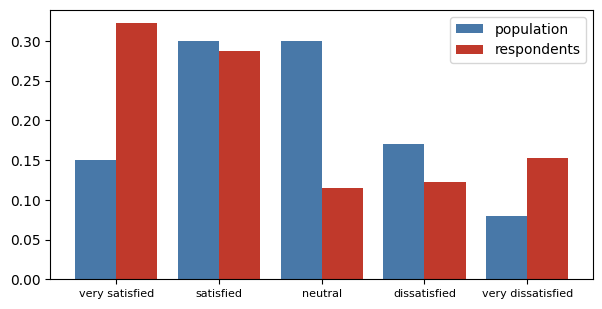

In [5]:
groups = ["very satisfied", "satisfied", "neutral", "dissatisfied", "very dissatisfied"]
true_share = np.array([0.15, 0.30, 0.30, 0.17, 0.08])
score = np.array([5, 4, 3, 2, 1])
resp_rate = np.array([0.45, 0.20, 0.08, 0.15, 0.40])     # extremes reply

observed = true_share*resp_rate
observed = observed/observed.sum()
print(f"true mean satisfaction      : {(true_share*score).sum():.3f}")
print(f"observed (survey) mean      : {(observed*score).sum():.3f}")

weights = true_share/observed          # weight back to the known population mix
print(f"weighted back to population : {(observed*weights*score).sum():.3f}   <-- exact, because")
print("we knew the true composition AND the only distortion was on that variable.")

x = np.arange(len(groups))
plt.bar(x-0.2, true_share, 0.4, label="population", color="#4878a8")
plt.bar(x+0.2, observed, 0.4, label="respondents", color="#c0392b")
plt.xticks(x, groups, fontsize=8); plt.legend(); plt.show()

## 5. Missing values hiding as zeros, in real clinical data



In [6]:
dia = pd.read_csv("https://richardson.byu.edu/220/diabetes.csv")
for col in ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]:
    z = (dia[col] == 0).sum()
    print(f"{col:>15}: {z:>4} zeros ({z/len(dia):5.1%}) "
          f"{'  <-- physiologically impossible' if z > 0 else ''}")

        Glucose:    5 zeros ( 0.7%)   <-- physiologically impossible
  BloodPressure:    0 zeros ( 0.0%) 
  SkinThickness:  194 zeros (26.5%)   <-- physiologically impossible
        Insulin:  339 zeros (46.2%)   <-- physiologically impossible
            BMI:    4 zeros ( 0.5%)   <-- physiologically impossible


In [7]:
ins_all = dia["Insulin"]
real = ins_all[ins_all > 0]
imputed = pd.concat([real, pd.Series([real.mean()]*int((ins_all == 0).sum()))])

print(f"{'approach':>28} {'mean':>9} {'SD':>9}")
print(f"{'keep the zeros (wrong)':>28} {ins_all.mean():>9.1f} {ins_all.std():>9.1f}")
print(f"{'drop them':>28} {real.mean():>9.1f} {real.std():>9.1f}")
print(f"{'impute the mean':>28} {imputed.mean():>9.1f} {imputed.std():>9.1f}")
print("\nMean imputation keeps the mean and shrinks the SD: it invents precision.")

# Is the missingness related to the outcome?
rate_missing = dia.loc[dia.Insulin == 0, "Outcome"].mean()
rate_present = dia.loc[dia.Insulin > 0, "Outcome"].mean()
print(f"\ndiabetes rate where insulin is MISSING : {rate_missing:.3f}")
print(f"diabetes rate where insulin is present  : {rate_present:.3f}")
print("If those differ, the missingness carries information and dropping rows changes the population.")

                    approach      mean        SD
      keep the zeros (wrong)      83.6     116.6
                   drop them     155.5     118.8
             impute the mean     155.5      87.0

Mean imputation keeps the mean and shrinks the SD: it invents precision.

diabetes rate where insulin is MISSING : 0.360
diabetes rate where insulin is present  : 0.330
If those differ, the missingness carries information and dropping rows changes the population.
